# Check time format in input file

In [3]:
import netCDF4 as nc
import numpy as np
from datetime import datetime
import cftime

# Path to your data file
data_file = "/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/ERA5_WRF_combined_concatenated_432/2024-04-30_2024-05-30_21.nc"

# Open the NetCDF file
with nc.Dataset(data_file, 'r') as ds:
    print("=" * 60)
    print("NetCDF File Information")
    print("=" * 60)
    
    # Print all variable names
    print("\nAvailable variables:")
    for var_name in ds.variables.keys():
        print(f"  - {var_name}")
    
    # Check for time variable
    time_var_names = ['time', 'Time', 'TIME', 't']
    time_var = None
    
    for var_name in time_var_names:
        if var_name in ds.variables:
            time_var = ds.variables[var_name]
            print(f"\nFound time variable: '{var_name}'")
            break
    
    if time_var is not None:
        print(f"Time variable shape: {time_var.shape}")
        print(f"Time variable attributes:")
        for attr_name in time_var.ncattrs():
            print(f"  {attr_name}: {getattr(time_var, attr_name)}")
        
        # Get time values
        time_values = time_var[:]
        print(f"\nNumber of time steps: {len(time_values)}")
        
        # Try to convert time values to readable format
        try:
            # Check if it has units attribute
            if hasattr(time_var, 'units'):
                units = time_var.units
                calendar = getattr(time_var, 'calendar', 'standard')
                
                print(f"Time units: {units}")
                print(f"Calendar: {calendar}")
                
                # Convert to datetime objects
                dates = cftime.num2date(time_values, units, calendar)
                
                print("\nAvailable times (first 10 and last 10):")
                print("-" * 40)
                
                # Show first 10 times
                for i, date in enumerate(dates[:10]):
                    if hasattr(date, 'strftime'):
                        date_str = date.strftime("%Y-%m-%dT%H:%M:%S")
                    else:
                        date_str = str(date)
                    print(f"  {i:2d}: {date_str}")
                
                if len(dates) > 10:
                    if len(dates) > 20:
                        print("  ...")
                    
                    # Show last 10 times
                    start_idx = max(10, len(dates) - 10)
                    for i, date in enumerate(dates[start_idx:], start_idx):
                        if hasattr(date, 'strftime'):
                            date_str = date.strftime("%Y-%m-%dT%H:%M:%S")
                        else:
                            date_str = str(date)
                        print(f"  {i:2d}: {date_str}")
                
                # Generate config-ready time list
                print("\n" + "=" * 60)
                print("YAML Config Format (all times):")
                print("=" * 60)
                print("times:")
                for date in dates:
                    if hasattr(date, 'strftime'):
                        date_str = date.strftime("%Y-%m-%dT%H:%M:%S")
                    else:
                        # Handle cftime objects
                        date_str = f"{date.year:04d}-{date.month:02d}-{date.day:02d}T{date.hour:02d}:{date.minute:02d}:{date.second:02d}"
                    print(f'    - "{date_str}"')
                
                print("\n" + "=" * 60)
                print("YAML Config Format (sample every 2 days):")
                print("=" * 60)
                print("times:")
                for i, date in enumerate(dates[::2]):  # Every 2nd time step
                    if hasattr(date, 'strftime'):
                        date_str = date.strftime("%Y-%m-%dT%H:%M:%S")
                    else:
                        date_str = f"{date.year:04d}-{date.month:02d}-{date.day:02d}T{date.hour:02d}:{date.minute:02d}:{date.second:02d}"
                    print(f'    - "{date_str}"')
                
            else:
                print("Time variable has no 'units' attribute")
                print("Raw time values (first 10):")
                for i, val in enumerate(time_values[:10]):
                    print(f"  {i:2d}: {val}")
                    
        except Exception as e:
            print(f"Error processing time values: {e}")
            print("Raw time values (first 10):")
            for i, val in enumerate(time_values[:10]):
                print(f"  {i:2d}: {val}")
    else:
        print("\nNo time variable found!")
        print("Available variables were:")
        for var_name in ds.variables.keys():
            print(f"  - {var_name}")
    
    # Check dimensions
    print(f"\n" + "=" * 60)
    print("Dataset Dimensions:")
    print("=" * 60)
    for dim_name, dim in ds.dimensions.items():
        print(f"  {dim_name}: {len(dim)}")
    
    # Check global attributes
    print(f"\n" + "=" * 60)
    print("Global Attributes:")
    print("=" * 60)
    for attr_name in ds.ncattrs():
        print(f"  {attr_name}: {getattr(ds, attr_name)}")

NetCDF File Information

Available variables:
  - time
  - coord

Found time variable: 'time'
Time variable shape: (504,)
Time variable attributes:
  units: seconds since 1970-01-01 00:00:00
  calendar: standard

Number of time steps: 504
Time units: seconds since 1970-01-01 00:00:00
Calendar: standard

Available times (first 10 and last 10):
----------------------------------------
   0: 2024-04-30T00:00:00
   1: 2024-04-30T01:00:00
   2: 2024-04-30T02:00:00
   3: 2024-04-30T03:00:00
   4: 2024-04-30T04:00:00
   5: 2024-04-30T05:00:00
   6: 2024-04-30T06:00:00
   7: 2024-04-30T07:00:00
   8: 2024-04-30T08:00:00
   9: 2024-04-30T09:00:00
  ...
  494: 2024-05-30T14:00:00
  495: 2024-05-30T15:00:00
  496: 2024-05-30T16:00:00
  497: 2024-05-30T17:00:00
  498: 2024-05-30T18:00:00
  499: 2024-05-30T19:00:00
  500: 2024-05-30T20:00:00
  501: 2024-05-30T21:00:00
  502: 2024-05-30T22:00:00
  503: 2024-05-30T23:00:00

YAML Config Format (all times):
times:
    - "2024-04-30T00:00:00"
    - "202

# Check outputs


Analyzing Q2_rain_rate results...
CorrDiff Output Analysis - corrdiff_Q2_rain_rate_predictions_20260202_114327.nc
Truth group variables: ['Q2', 'Rain_rate']
Prediction group variables: ['Q2', 'Rain_rate']
Input group variables: ['t_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sp', 'tcwv', 'tp']
Output variables for analysis: ['Q2', 'Rain_rate']

Analyzing variable: Q2

Q2 information:
  Truth shape: (1, 432, 432)
  Prediction shape: (8, 1, 432, 432)
  Truth dimensions: ('time', 'y', 'x')
  Prediction dimensions: ('ensemble', 'time', 'y', 'x')
  Number of time steps: 1
  Number of ensembles: 8

Q2 statistics:
  Truth - min: 0.0034, max: 0.0215, mean: 0.0141
  Prediction - min: -0.0009, max: 0.0273, mean: 0.0144

Performance metrics (time step 0):
  RMSE: 0.0019
  MAE: 0.0015
  Correlation: 0.8911
  R²: 0.7902
  Bias: 0.0002


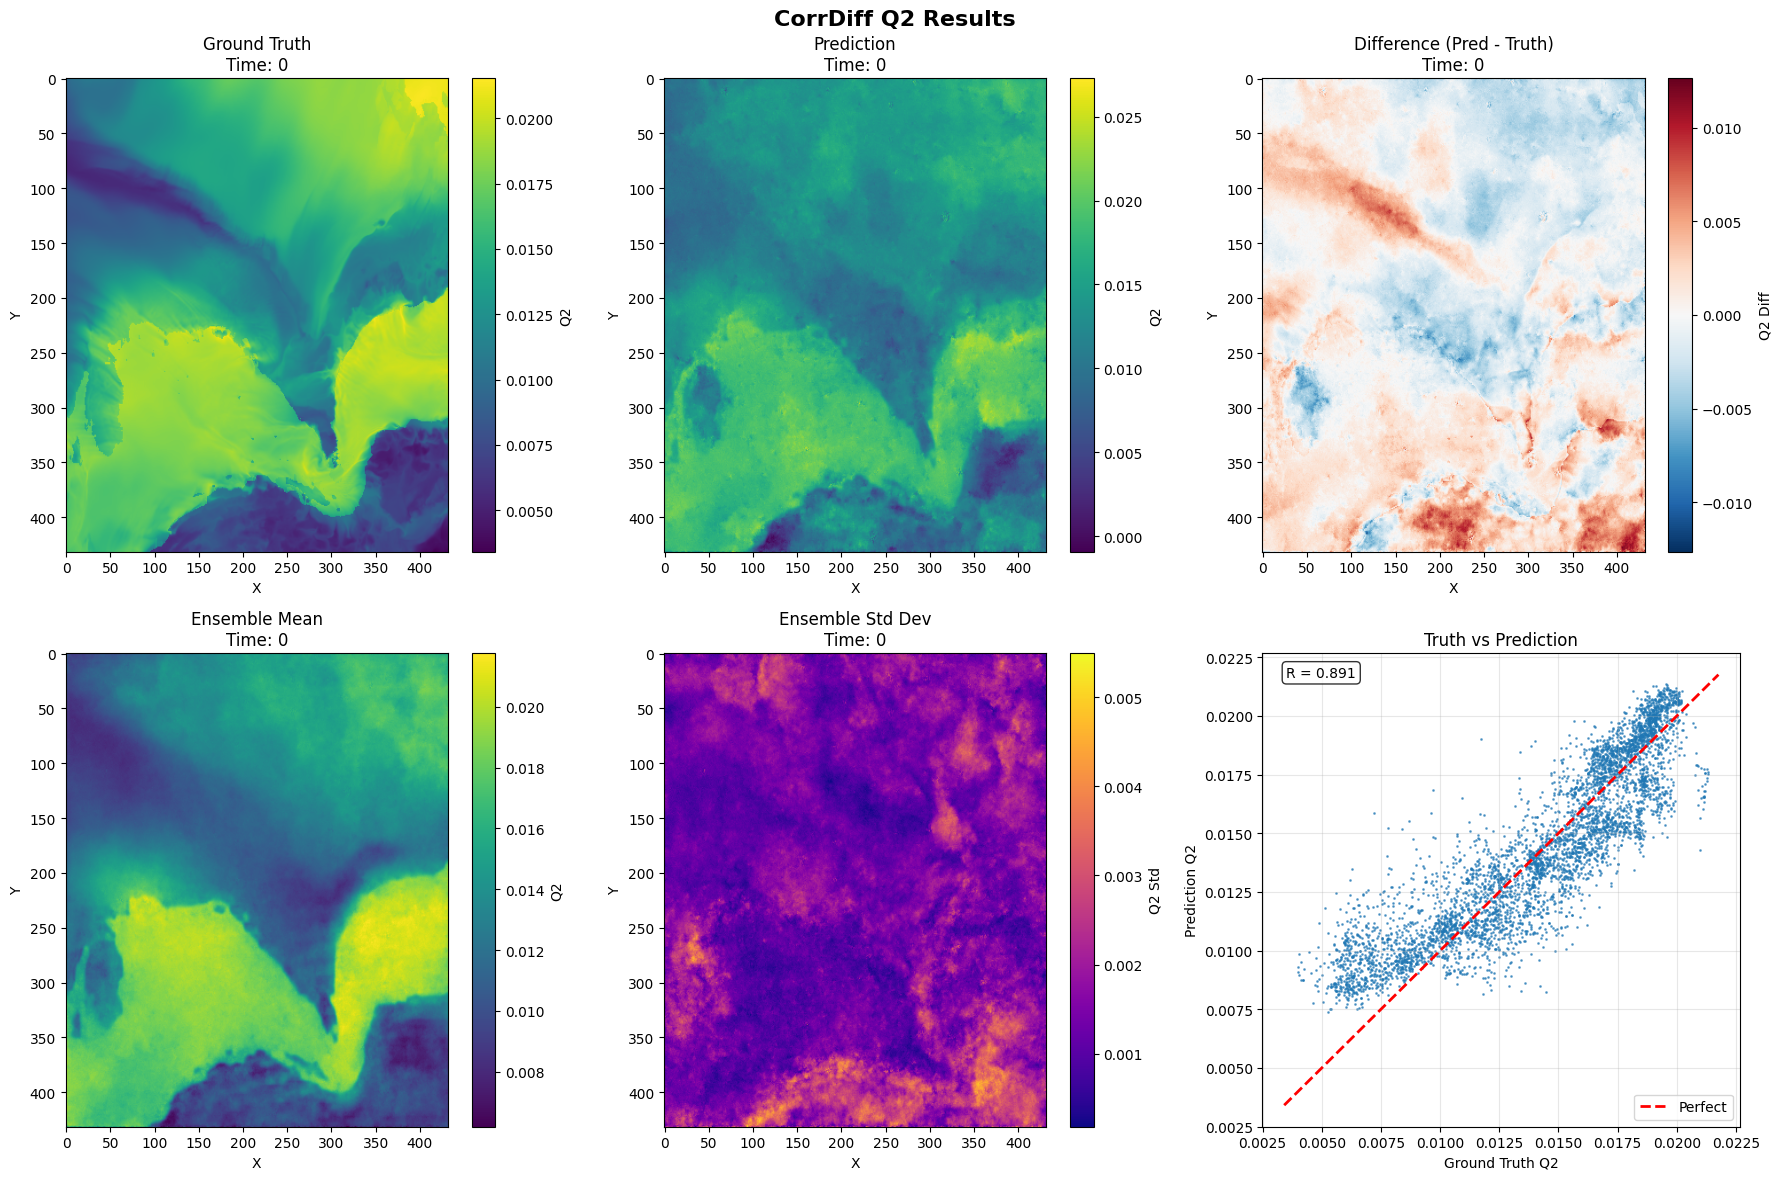


Analyzing variable: Rain_rate

Rain_rate information:
  Truth shape: (1, 432, 432)
  Prediction shape: (8, 1, 432, 432)
  Truth dimensions: ('time', 'y', 'x')
  Prediction dimensions: ('ensemble', 'time', 'y', 'x')
  Number of time steps: 1
  Number of ensembles: 8

Rain_rate statistics:
  Truth - min: 0.0000, max: 0.5068, mean: 0.0000
  Prediction - min: -0.3269, max: 5.9338, mean: 0.0025

Performance metrics (time step 0):
  RMSE: 0.0178
  MAE: 0.0072
  Correlation: -0.0003
  R²: -166.9020
  Bias: 0.0025


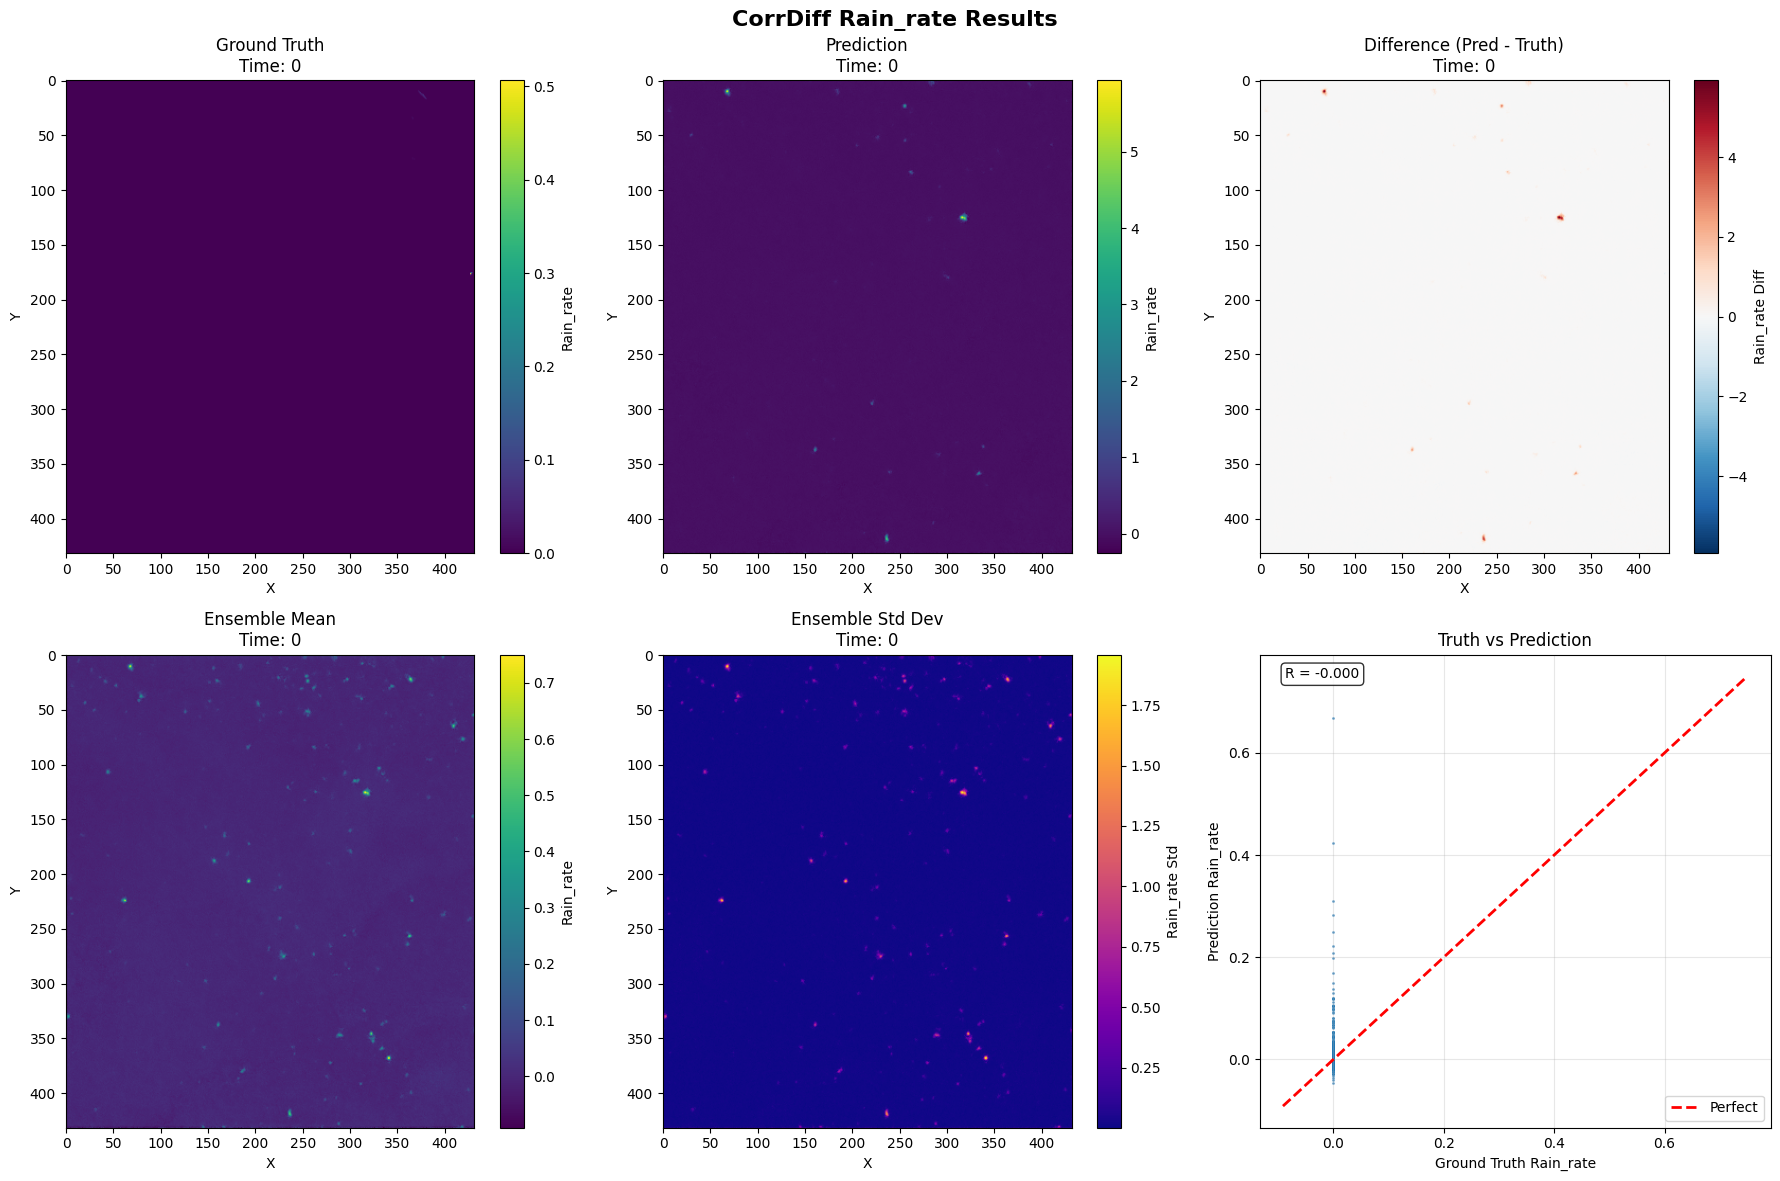

In [29]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import List, Dict, Tuple, Optional, Any
import os

class CorrDiffAnalyzer:
    """Modular analyzer for CorrDiff model outputs."""
    
    def __init__(self, output_file: str):
        """
        Initialize the analyzer with an output file.
        
        Args:
            output_file: Path to the NetCDF output file
        """
        self.output_file = output_file
        self.truth_ds = None
        self.pred_ds = None
        self.input_ds = None
        self.output_variables = []
        self.analysis_results = {}
        
    def load_datasets(self) -> bool:
        """Load the NetCDF datasets from groups."""
        try:
            self.truth_ds = xr.open_dataset(self.output_file, group="truth")
            self.pred_ds = xr.open_dataset(self.output_file, group="prediction")
            self.input_ds = xr.open_dataset(self.output_file, group="input")
            
            # Get output variables (data variables, not coordinates)
            self.output_variables = [var for var in self.truth_ds.data_vars.keys()]
            
            print(f"Truth group variables: {list(self.truth_ds.variables.keys())}")
            print(f"Prediction group variables: {list(self.pred_ds.variables.keys())}")
            print(f"Input group variables: {list(self.input_ds.variables.keys())}")
            print(f"Output variables for analysis: {self.output_variables}")
            
            return True
            
        except Exception as e:
            print(f"Error loading datasets: {e}")
            return False
    
    def get_dataset_info(self, variable_name: str) -> Dict[str, Any]:
        """Get information about a specific variable."""
        if variable_name not in self.output_variables:
            raise ValueError(f"Variable {variable_name} not found in output variables")
        
        truth_var = self.truth_ds[variable_name]
        pred_var = self.pred_ds[variable_name]
        
        info = {
            'variable_name': variable_name,
            'truth_shape': truth_var.shape,
            'pred_shape': pred_var.shape,
            'truth_dims': truth_var.dims,
            'pred_dims': pred_var.dims,
            'truth_coords': list(truth_var.coords),
            'pred_coords': list(pred_var.coords),
        }
        
        # Time information
        if 'time' in self.truth_ds.coords:
            times_coord = self.truth_ds.time
            info['n_times'] = len(times_coord)
            info['first_time'] = times_coord.values[0]
            info['last_time'] = times_coord.values[-1]
            info['has_time_coord'] = True
        else:
            info['n_times'] = truth_var.shape[0]
            info['has_time_coord'] = False
        
        # Ensemble information
        if 'ensemble' in pred_var.dims:
            info['n_ensembles'] = pred_var.shape[pred_var.dims.index('ensemble')]
            info['has_ensemble'] = True
        else:
            info['n_ensembles'] = 1
            info['has_ensemble'] = False
        
        # Statistics
        info['truth_stats'] = {
            'min': float(truth_var.min().values),
            'max': float(truth_var.max().values),
            'mean': float(truth_var.mean().values),
            'std': float(truth_var.std().values)
        }
        
        info['pred_stats'] = {
            'min': float(pred_var.min().values),
            'max': float(pred_var.max().values),
            'mean': float(pred_var.mean().values),
            'std': float(pred_var.std().values)
        }
        
        return info
    
    def calculate_metrics(self, variable_name: str, time_idx: int = 0) -> Dict[str, float]:
        """Calculate performance metrics for a variable at a specific time."""
        truth_var = self.truth_ds[variable_name]
        pred_var = self.pred_ds[variable_name]
        
        truth_sample = truth_var.isel(time=time_idx)
        
        if 'ensemble' in pred_var.dims:
            pred_sample = pred_var.isel(time=time_idx).mean(dim='ensemble')
        else:
            pred_sample = pred_var.isel(time=time_idx)
        
        # Calculate metrics
        rmse = float(np.sqrt(((pred_sample - truth_sample)**2).mean().values))
        mae = float(np.abs(pred_sample - truth_sample).mean().values)
        bias = float((pred_sample - truth_sample).mean().values)
        
        # Correlation
        truth_flat = truth_sample.values.flatten()
        pred_flat = pred_sample.values.flatten()
        corr = np.corrcoef(truth_flat, pred_flat)[0, 1]
        
        # R²
        ss_res = float(((truth_sample - pred_sample)**2).sum().values)
        ss_tot = float(((truth_sample - truth_sample.mean())**2).sum().values)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        return {
            'rmse': rmse,
            'mae': mae,
            'bias': bias,
            'correlation': corr,
            'r2': r2
        }
    
    def calculate_time_series_metrics(self, variable_name: str) -> Dict[str, List[float]]:
        """Calculate metrics across all time steps for a variable."""
        info = self.get_dataset_info(variable_name)
        n_times = info['n_times']
        
        metrics = {
            'rmse': [],
            'mae': [],
            'bias': [],
            'correlation': [],
            'r2': []
        }
        
        for t in range(n_times):
            t_metrics = self.calculate_metrics(variable_name, time_idx=t)
            for metric, value in t_metrics.items():
                metrics[metric].append(value)
        
        return metrics
    
    def plot_variable_analysis(self, variable_name: str, time_idx: int = 0, 
                             figsize: Tuple[int, int] = (18, 12)) -> plt.Figure:
        """Create visualization plots for a specific variable."""
        truth_var = self.truth_ds[variable_name]
        pred_var = self.pred_ds[variable_name]
        
        # Select data for plotting
        truth_sample = truth_var.isel(time=time_idx)
        
        if 'ensemble' in pred_var.dims:
            ensemble_idx = 0
            pred_sample = pred_var.isel(time=time_idx, ensemble=ensemble_idx)
            ensemble_mean = pred_var.isel(time=time_idx).mean(dim='ensemble')
            ensemble_std = pred_var.isel(time=time_idx).std(dim='ensemble')
        else:
            pred_sample = pred_var.isel(time=time_idx)
            ensemble_mean = pred_sample
            ensemble_std = np.zeros_like(pred_sample)
        
        # Create plots
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle(f'CorrDiff {variable_name} Results', fontsize=16, fontweight='bold')
        
        # Plot 1: Ground Truth
        im1 = axes[0, 0].imshow(truth_sample, cmap='viridis', aspect='auto')
        axes[0, 0].set_title(f'Ground Truth\nTime: {time_idx}')
        axes[0, 0].set_xlabel('X')
        axes[0, 0].set_ylabel('Y')
        plt.colorbar(im1, ax=axes[0, 0], label=variable_name)
        
        # Plot 2: Prediction
        im2 = axes[0, 1].imshow(pred_sample, cmap='viridis', aspect='auto')
        axes[0, 1].set_title(f'Prediction\nTime: {time_idx}')
        axes[0, 1].set_xlabel('X')
        axes[0, 1].set_ylabel('Y')
        plt.colorbar(im2, ax=axes[0, 1], label=variable_name)
        
        # Plot 3: Difference
        diff = pred_sample - truth_sample
        vmax = max(abs(diff.min().values), abs(diff.max().values))
        im3 = axes[0, 2].imshow(diff, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
        axes[0, 2].set_title(f'Difference (Pred - Truth)\nTime: {time_idx}')
        axes[0, 2].set_xlabel('X')
        axes[0, 2].set_ylabel('Y')
        plt.colorbar(im3, ax=axes[0, 2], label=f'{variable_name} Diff')
        
        # Plot 4: Ensemble mean
        im4 = axes[1, 0].imshow(ensemble_mean, cmap='viridis', aspect='auto')
        axes[1, 0].set_title(f'Ensemble Mean\nTime: {time_idx}')
        axes[1, 0].set_xlabel('X')
        axes[1, 0].set_ylabel('Y')
        plt.colorbar(im4, ax=axes[1, 0], label=variable_name)
        
        # Plot 5: Ensemble standard deviation
        im5 = axes[1, 1].imshow(ensemble_std, cmap='plasma', aspect='auto')
        axes[1, 1].set_title(f'Ensemble Std Dev\nTime: {time_idx}')
        axes[1, 1].set_xlabel('X')
        axes[1, 1].set_ylabel('Y')
        plt.colorbar(im5, ax=axes[1, 1], label=f'{variable_name} Std')
        
        # Plot 6: Scatter plot
        truth_flat = truth_sample.values.flatten()
        pred_flat = ensemble_mean.values.flatten()
        
        sample_size = min(5000, len(truth_flat))
        idx = np.random.choice(len(truth_flat), sample_size, replace=False)
        
        axes[1, 2].scatter(truth_flat[idx], pred_flat[idx], alpha=0.6, s=1)
        
        min_val = min(truth_flat.min(), pred_flat.min())
        max_val = max(truth_flat.max(), pred_flat.max())
        axes[1, 2].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')
        
        axes[1, 2].set_xlabel(f'Ground Truth {variable_name}')
        axes[1, 2].set_ylabel(f'Prediction {variable_name}')
        axes[1, 2].set_title('Truth vs Prediction')
        axes[1, 2].grid(True, alpha=0.3)
        axes[1, 2].legend()
        
        # Add correlation coefficient
        corr = np.corrcoef(truth_flat, pred_flat)[0, 1]
        axes[1, 2].text(0.05, 0.95, f'R = {corr:.3f}', transform=axes[1, 2].transAxes, 
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        return fig
    
    def plot_time_series_metrics(self, variable_name: str, 
                               figsize: Tuple[int, int] = (18, 10)) -> plt.Figure:
        """Plot time series of performance metrics."""
        metrics = self.calculate_time_series_metrics(variable_name)
        info = self.get_dataset_info(variable_name)
        n_times = info['n_times']
        
        if n_times <= 1:
            print(f"Only {n_times} time step(s) available, skipping time series analysis")
            return None
        
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle(f'Performance Metrics Over Time - {variable_name}', fontsize=16, fontweight='bold')
        
        time_range = range(n_times)
        
        # RMSE over time
        axes[0, 0].plot(time_range, metrics['rmse'], 'b-o', linewidth=2, markersize=4)
        axes[0, 0].set_xlabel('Time Step')
        axes[0, 0].set_ylabel('RMSE')
        axes[0, 0].set_title('RMSE Over Time')
        axes[0, 0].grid(True, alpha=0.3)
        
        # MAE over time
        axes[0, 1].plot(time_range, metrics['mae'], 'g-o', linewidth=2, markersize=4)
        axes[0, 1].set_xlabel('Time Step')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].set_title('MAE Over Time')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Correlation over time
        axes[0, 2].plot(time_range, metrics['correlation'], 'm-o', linewidth=2, markersize=4)
        axes[0, 2].set_xlabel('Time Step')
        axes[0, 2].set_ylabel('Correlation')
        axes[0, 2].set_title('Correlation Over Time')
        axes[0, 2].grid(True, alpha=0.3)
        axes[0, 2].set_ylim([0, 1])
        
        # R² over time
        axes[1, 0].plot(time_range, metrics['r2'], 'r-o', linewidth=2, markersize=4)
        axes[1, 0].set_xlabel('Time Step')
        axes[1, 0].set_ylabel('R²')
        axes[1, 0].set_title('R² Over Time')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_ylim([0, 1])
        
        # Bias over time
        axes[1, 1].plot(time_range, metrics['bias'], 'orange', linewidth=2, marker='o', markersize=4)
        axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
        axes[1, 1].set_xlabel('Time Step')
        axes[1, 1].set_ylabel('Bias')
        axes[1, 1].set_title('Bias Over Time')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Summary statistics
        axes[1, 2].axis('off')
        summary_text = f"""
SUMMARY STATISTICS
{variable_name}
(Across all {n_times} time steps)

RMSE:
  Mean: {np.mean(metrics['rmse']):.4f}
  Std:  {np.std(metrics['rmse']):.4f}
  Min:  {np.min(metrics['rmse']):.4f}
  Max:  {np.max(metrics['rmse']):.4f}

Correlation:
  Mean: {np.mean(metrics['correlation']):.4f}
  Std:  {np.std(metrics['correlation']):.4f}
  Min:  {np.min(metrics['correlation']):.4f}
  Max:  {np.max(metrics['correlation']):.4f}

R²:
  Mean: {np.mean(metrics['r2']):.4f}
  Std:  {np.std(metrics['r2']):.4f}
  Min:  {np.min(metrics['r2']):.4f}
  Max:  {np.max(metrics['r2']):.4f}
        """
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes,
                        fontfamily='monospace', fontsize=10, verticalalignment='top',
                        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
        
        plt.tight_layout()
        return fig
    
    def analyze_all_variables(self, time_idx: int = 0, show_plots: bool = True) -> Dict[str, Any]:
        """Analyze all variables in the dataset."""
        results = {}
        
        print("=" * 60)
        print(f"CorrDiff Output Analysis - {os.path.basename(self.output_file)}")
        print("=" * 60)
        
        if not self.load_datasets():
            return results
        
        for var_name in self.output_variables:
            print(f"\n{'='*60}")
            print(f"Analyzing variable: {var_name}")
            print('='*60)
            
            try:
                # Get basic information
                info = self.get_dataset_info(var_name)
                
                # Print information
                print(f"\n{var_name} information:")
                print(f"  Truth shape: {info['truth_shape']}")
                print(f"  Prediction shape: {info['pred_shape']}")
                print(f"  Truth dimensions: {info['truth_dims']}")
                print(f"  Prediction dimensions: {info['pred_dims']}")
                print(f"  Number of time steps: {info['n_times']}")
                print(f"  Number of ensembles: {info['n_ensembles']}")
                
                print(f"\n{var_name} statistics:")
                print(f"  Truth - min: {info['truth_stats']['min']:.4f}, "
                      f"max: {info['truth_stats']['max']:.4f}, "
                      f"mean: {info['truth_stats']['mean']:.4f}")
                print(f"  Prediction - min: {info['pred_stats']['min']:.4f}, "
                      f"max: {info['pred_stats']['max']:.4f}, "
                      f"mean: {info['pred_stats']['mean']:.4f}")
                
                # Calculate metrics for first time step
                metrics = self.calculate_metrics(var_name, time_idx)
                
                print(f"\nPerformance metrics (time step {time_idx}):")
                print(f"  RMSE: {metrics['rmse']:.4f}")
                print(f"  MAE: {metrics['mae']:.4f}")
                print(f"  Correlation: {metrics['correlation']:.4f}")
                print(f"  R²: {metrics['r2']:.4f}")
                print(f"  Bias: {metrics['bias']:.4f}")
                
                # Calculate time series metrics if multiple time steps
                if info['n_times'] > 1:
                    ts_metrics = self.calculate_time_series_metrics(var_name)
                    
                    print(f"\nTime series summary (across all {info['n_times']} time steps):")
                    print(f"  RMSE: {np.mean(ts_metrics['rmse']):.4f} ± {np.std(ts_metrics['rmse']):.4f}")
                    print(f"  MAE: {np.mean(ts_metrics['mae']):.4f} ± {np.std(ts_metrics['mae']):.4f}")
                    print(f"  Correlation: {np.mean(ts_metrics['correlation']):.4f} ± {np.std(ts_metrics['correlation']):.4f}")
                    print(f"  R²: {np.mean(ts_metrics['r2']):.4f} ± {np.std(ts_metrics['r2']):.4f}")
                    print(f"  Bias: {np.mean(ts_metrics['bias']):.4f} ± {np.std(ts_metrics['bias']):.4f}")
                
                # Store results
                results[var_name] = {
                    'info': info,
                    'metrics': metrics,
                    'time_series_metrics': ts_metrics if info['n_times'] > 1 else None
                }
                
                # Create plots
                if show_plots:
                    # Main analysis plot
                    fig1 = self.plot_variable_analysis(var_name, time_idx)
                    plt.show()
                    
                    # Time series plot if applicable
                    if info['n_times'] > 1:
                        fig2 = self.plot_time_series_metrics(var_name)
                        if fig2 is not None:
                            plt.show()
                
            except Exception as e:
                print(f"Error analyzing {var_name}: {e}")
                import traceback
                traceback.print_exc()
                results[var_name] = {'error': str(e)}
        
        return results
    
    def close_datasets(self):
        """Close all open datasets."""
        if self.truth_ds is not None:
            self.truth_ds.close()
        if self.pred_ds is not None:
            self.pred_ds.close()
        if self.input_ds is not None:
            self.input_ds.close()

def analyze_corrdiff_output(output_file: str, time_idx: int = 0, show_plots: bool = True) -> Dict[str, Any]:
    """
    Convenience function to analyze a CorrDiff output file.
    
    Args:
        output_file: Path to the NetCDF output file
        time_idx: Time index for detailed analysis (default: 0)
        show_plots: Whether to display plots (default: True)
    
    Returns:
        Dictionary with analysis results for all variables
    """
    analyzer = CorrDiffAnalyzer(output_file)
    try:
        results = analyzer.analyze_all_variables(time_idx=time_idx, show_plots=show_plots)
        return results
    finally:
        analyzer.close_datasets()

# Usage examples:
if __name__ == "__main__":
    # # Example 1: Fog_index analysis
    # fog_file = "/app/outputs/generation/Fog_index/corrdiff_Fog_index_predictions_20260202_074227.nc"
    # if os.path.exists(fog_file):
    #     print("Analyzing Fog_index results...")
    #     fog_results = analyze_corrdiff_output(fog_file)
    
    # Example 2: Q2_rain_rate analysis
    rain_file = "/app/outputs/generation/Q2_rain_rate/corrdiff_Q2_rain_rate_predictions_20260202_114327.nc"
    if os.path.exists(rain_file):
        print("\nAnalyzing Q2_rain_rate results...")
        rain_results = analyze_corrdiff_output(rain_file)
    
    # Example 3: Analyze specific variable from a file
    # analyzer = CorrDiffAnalyzer(output_file)
    # analyzer.load_datasets()
    # specific_metrics = analyzer.calculate_metrics("Fog_index", time_idx=0)
    # analyzer.plot_variable_analysis("Fog_index")
    # analyzer.close_datasets()

In [9]:
output_file = "/app/outputs/generation/Q2_rain_rate/corrdiff_Q2_rain_rate_predictions_20260202_093138.nc"
truth_ds = xr.open_dataset(output_file, group="truth")
pred_ds = xr.open_dataset(output_file, group="prediction")
input_ds = xr.open_dataset(output_file, group="input")

In [13]:
pred_ds

<xarray.Dataset> Size: 48MB
Dimensions:    (ensemble: 4, time: 8, y: 432, x: 432)
Dimensions without coordinates: ensemble, time, y, x
Data variables:
    Q2         (ensemble, time, y, x) float32 24MB ...
    Rain_rate  (ensemble, time, y, x) float32 24MB ...

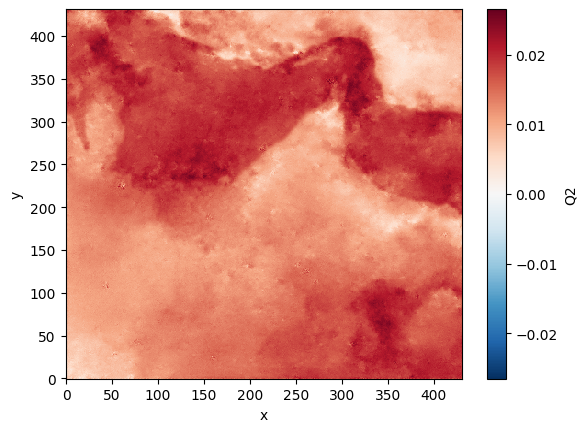

In [30]:
pred_ds['Q2'][1,1].plot()